In [20]:
import sys
sys.path.insert(0, '..')  # permite importar o pacote mlp/ a partir do diretório raiz

import numpy as np
import matplotlib.pyplot as plt

from mlp.network import MLP          # classe principal: forward + backprop
from mlp.losses import cross_entropy  # função de perda para classificação
from mlp.optimizers import SGD, treinar  # otimizador e loop de treinamento

In [ ]:
# XOR: os quatro pontos possíveis com suas classes
X_xor = np.array([[0, 0],
                   [0, 1],
                   [1, 0],
                   [1, 1]], dtype=float)

# one-hot encoding: [1,0] = classe 0 (false)  |  [0,1] = classe 1 (true)
y_xor = np.array([[1, 0],
                   [0, 1],
                   [0, 1],
                   [1, 0]])

np.random.seed(42)  # garante reprodutibilidade

rede_xor = MLP([2, 8, 2])
otimizador_xor = SGD(taxa_aprendizado=0.1)  # lr maior: dataset pequeno, pode ser agressivo

historico_xor = treinar(
    rede_xor, otimizador_xor, cross_entropy,
    X_xor, y_xor,
    epocas=500,       
    tamanho_lote=4  
)

print(f'\nPredicoes: {rede_xor.predict(X_xor)}')
print(f'Esperado:  [0 1 1 0]')

Epoca   1/500  perda: 0.6440  acuracia: 0.5000
Epoca   5/500  perda: 0.5834  acuracia: 0.7500
Epoca  10/500  perda: 0.5398  acuracia: 0.7500
Epoca  15/500  perda: 0.5083  acuracia: 0.7500
Epoca  20/500  perda: 0.4841  acuracia: 1.0000
Epoca  25/500  perda: 0.4650  acuracia: 1.0000
Epoca  30/500  perda: 0.4431  acuracia: 1.0000
Epoca  35/500  perda: 0.4203  acuracia: 1.0000
Epoca  40/500  perda: 0.3999  acuracia: 1.0000
Epoca  45/500  perda: 0.3788  acuracia: 1.0000
Epoca  50/500  perda: 0.3593  acuracia: 1.0000
Epoca  55/500  perda: 0.3432  acuracia: 1.0000
Epoca  60/500  perda: 0.3304  acuracia: 1.0000
Epoca  65/500  perda: 0.3178  acuracia: 1.0000
Epoca  70/500  perda: 0.3045  acuracia: 1.0000
Epoca  75/500  perda: 0.2920  acuracia: 1.0000
Epoca  80/500  perda: 0.2799  acuracia: 1.0000
Epoca  85/500  perda: 0.2676  acuracia: 1.0000
Epoca  90/500  perda: 0.2548  acuracia: 1.0000
Epoca  95/500  perda: 0.2432  acuracia: 1.0000
Epoca 100/500  perda: 0.2322  acuracia: 1.0000
Epoca 105/500

In [ ]:
from keras.datasets import mnist  # Keras standalone (não usa TensorFlow)

(X_treino, y_treino), (X_teste, y_teste) = mnist.load_data()

X_treino = X_treino.reshape(-1, 784).astype(float) / 255.0
X_teste  = X_teste.reshape(-1, 784).astype(float) / 255.0

def one_hot(y, num_classes=10):
    resultado = np.zeros((len(y), num_classes))
    resultado[np.arange(len(y)), y] = 1
    return resultado

y_treino_oh = one_hot(y_treino)  # (60000, 10)
y_teste_oh  = one_hot(y_teste)   # (10000, 10)

print(f'Treino: {X_treino.shape}  Teste: {X_teste.shape}')

Treino: (60000, 784)  Teste: (10000, 784)


In [27]:
np.random.seed(42)  

# arquitetura: entrada (784) → oculta 1 (128, ReLU) → oculta 2 (64, ReLU) → saída (10, Softmax)
# He initialization é aplicada automaticamente dentro da classe MLP
rede = MLP([784, 128, 64, 10])

otimizador = SGD(taxa_aprendizado=0.1)

historico = treinar(
    rede, otimizador, cross_entropy,
    X_treino, y_treino_oh,
    epocas=20,         
    tamanho_lote=64     
)

Epoca   1/20  perda: 0.3317  acuracia: 0.9498
Epoca   5/20  perda: 0.0706  acuracia: 0.9832
Epoca  10/20  perda: 0.0313  acuracia: 0.9933
Epoca  15/20  perda: 0.0132  acuracia: 0.9980
Epoca  20/20  perda: 0.0046  acuracia: 0.9998


In [28]:
predicoes_teste = rede.predict(X_teste)

acuracia_teste = np.mean(predicoes_teste == y_teste)
print(f'Acuracia no teste: {acuracia_teste*100:.2f}%')

Acuracia no teste: 97.91%


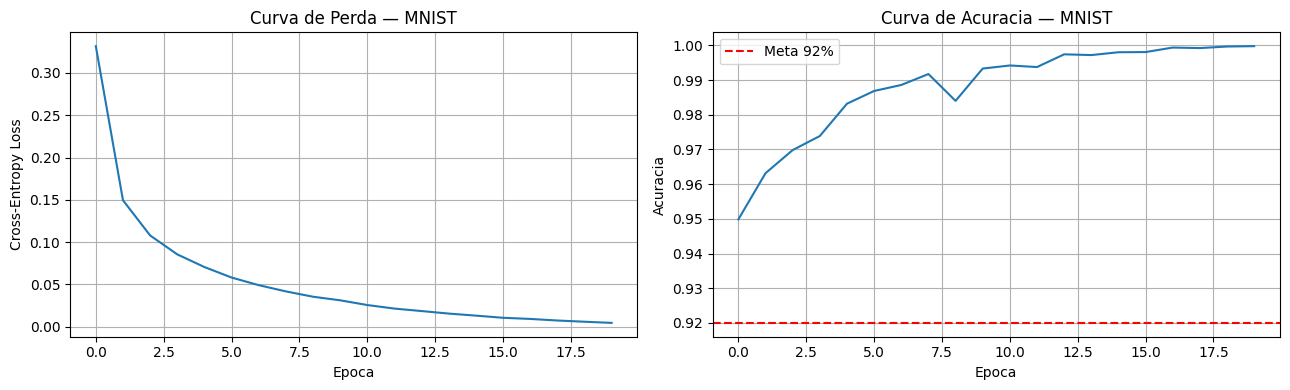

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(historico['perda'])
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Curva de Perda — MNIST')
ax1.grid(True)

ax2.plot(historico['acuracia'])
ax2.axhline(y=0.92, color='r', linestyle='--', label='Meta 92%')  # linha de referência da atividade
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Acuracia')
ax2.set_title('Curva de Acuracia — MNIST')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('../results/curvas_mnist.png', dpi=150)  # salva para o README
plt.show()

In [ ]:
experimentos = [
    {'nome': 'Baseline [784,128,64,10] lr=0.01', 'camadas': [784, 128, 64, 10],  'lr': 0.01, 'epocas': 20, 'lote': 64},
    {'nome': 'Maior lr=0.1',                     'camadas': [784, 128, 64, 10],  'lr': 0.1,  'epocas': 20, 'lote': 64},
    {'nome': 'Rede maior [784,256,128,10]',       'camadas': [784, 256, 128, 10], 'lr': 0.01, 'epocas': 20, 'lote': 64},
    {'nome': 'Lote menor batch=32',               'camadas': [784, 128, 64, 10],  'lr': 0.01, 'epocas': 20, 'lote': 32},
]

for exp in experimentos:
    np.random.seed(42)  
    otim_exp = SGD(taxa_aprendizado=exp['lr'])

    treinar(rede_exp, otim_exp, cross_entropy,
            X_treino, y_treino_oh,
            epocas=exp['epocas'], tamanho_lote=exp['lote'])

    acc = np.mean(rede_exp.predict(X_teste) == y_teste)
    print(f"{exp['nome']:45s} -> {acc*100:.2f}%")

Epoca   1/20  perda: 0.7956  acuracia: 0.8853
Epoca   5/20  perda: 0.2387  acuracia: 0.9359
Epoca  10/20  perda: 0.1642  acuracia: 0.9557
Epoca  15/20  perda: 0.1259  acuracia: 0.9665
Epoca  20/20  perda: 0.1015  acuracia: 0.9735
Baseline [784,128,64,10] lr=0.01              -> 96.73%
Epoca   1/20  perda: 0.3317  acuracia: 0.9498
Epoca   5/20  perda: 0.0706  acuracia: 0.9832
Epoca  10/20  perda: 0.0313  acuracia: 0.9933
Epoca  15/20  perda: 0.0132  acuracia: 0.9980
Epoca  20/20  perda: 0.0046  acuracia: 0.9998
Maior lr=0.1                                  -> 97.91%
Epoca   1/20  perda: 0.7525  acuracia: 0.8919
Epoca   5/20  perda: 0.2253  acuracia: 0.9393
Epoca  10/20  perda: 0.1552  acuracia: 0.9586
Epoca  15/20  perda: 0.1185  acuracia: 0.9673
Epoca  20/20  perda: 0.0947  acuracia: 0.9748
Rede maior [784,256,128,10]                   -> 96.83%
Epoca   1/20  perda: 0.5838  acuracia: 0.9065
Epoca   5/20  perda: 0.1738  acuracia: 0.9553
Epoca  10/20  perda: 0.1077  acuracia: 0.9718
Epoc